# Risk and Position Sizing

Stage 7.8 researches **how much capital participates in each trade** while keeping
EMA20/50's decisions and the shared backtest engine unchanged. This is historical
research: no exchange connection, orders, or real money.

```text
Market data → strategy intent → next-OPEN execution → trade ledger
                                                       ↓
                           fixed fraction → allowed capital budget
                                                       ↓
                            independent GROSS / NET trade accounting
                                                       ↓
                            reserve-aware equity → reusable analytics
```

Strategy decides **when** to be LONG or FLAT. The independent risk layer determines
**how much current capital** may be allocated. Accounting calculates quantity and
financial results; equity tracks cash plus holdings; analytics consumes those
canonical outputs. The pipeline orchestrates existing functions, without owning
the financial formulas.

Select the parent workspace's existing `.venv/` Python kernel. The setup below
finds `src/` from the notebook directory, project root, or parent workspace.

In [1]:
from pathlib import Path
import hashlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root_candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "Trading Lab"]
PROJECT_ROOT = next(
    (folder for folder in root_candidates if (folder / "src" / "trading_lab").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Trading Lab project root not found; open the project or notebook directory.")
source_directory = str(PROJECT_ROOT / "src")
if source_directory not in sys.path:
    sys.path.insert(0, source_directory)

from trading_lab.data.market_data import load_ohlcv_csv
from trading_lab.strategies.ema_trend import generate_ema_signals
from trading_lab.backtest.pipeline import run_backtest_pipeline
from trading_lab.risk.position_sizing import calculate_position_budget
from trading_lab.analytics.equity import (
    calculate_gross_mark_to_market_equity,
    calculate_net_mark_to_market_equity,
)
from trading_lab.analytics.drawdown import (
    summarize_gross_realized_drawdown, summarize_net_realized_drawdown,
)
from trading_lab.analytics.portfolio_drawdown import (
    summarize_gross_portfolio_drawdown, summarize_net_portfolio_drawdown,
)
from trading_lab.analytics.trade_time import summarize_trade_time_metrics
from trading_lab.analytics.risk_adjusted import (
    calculate_time_based_returns, summarize_risk_adjusted_performance,
)

%matplotlib inline
print("Project source imports ready; existing Python kernel:", sys.version.split()[0])

Matplotlib is building the font cache; this may take a moment.


Project source imports ready; existing Python kernel: 3.9.6


/Users/romankondratenko/trading-lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 1. Frozen data and explicit assumptions

Read only the saved **BTCUSDT 1-hour** snapshot: **2025-10-01 00:00 UTC through
2026-10-01 00:00 UTC, exclusive**, or 8,760 candles. The existing loader validates
its types and coverage. Check the accepted SHA-256 before loading; missing or
changed data stops execution. This notebook never downloads a replacement.

The strategy is EMA20/50 with 50 warm-up candles. Initial portfolio capital is
**10,000 USDT**. NET assumes a **0.10% fee per side** and **0.05% adverse slippage
per side**. These are fixed research assumptions, not current Bybit fee claims.
The allocation fractions are **1.0, 0.50, and 0.25**; everything else is shared.

In [2]:
CSV_PATH = PROJECT_ROOT / "data" / "raw" / "BTCUSDT_1h.csv"
START = pd.Timestamp("2025-10-01", tz="UTC")
END = pd.Timestamp("2026-10-01", tz="UTC")
HOUR = pd.Timedelta(hours=1)
FROZEN_SHA256 = "0be33013ae5decc74112c4a1cfdcb94b387830a37b9d1109b7f6c582d60f1975"
INITIAL_CAPITAL = 10_000.0
FEE_RATE = 0.001
SLIPPAGE_RATE = 0.0005
FRACTIONS = (1.0, 0.5, 0.25)

if not CSV_PATH.is_file():
    raise FileNotFoundError("Frozen local BTCUSDT snapshot missing. STOP: this notebook does not download data.")
raw_hash_before = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
assert raw_hash_before == FROZEN_SHA256, "STOP: frozen snapshot hash differs"
candles = load_ohlcv_csv(CSV_PATH, interval="60", start=START, end=END)
candles_before = candles.copy(deep=True)
assert len(candles) == 8760
assert candles.timestamp.iloc[0] == START
assert candles.timestamp.iloc[-1] == END - HOUR
assert candles.open.iloc[0] == 114_051.1

display(pd.Series({
    "candles": len(candles), "start_UTC": START, "end_exclusive_UTC": END,
    "first_raw_OPEN_USDT": candles.open.iloc[0], "snapshot_hash": "matches frozen SHA-256",
    "initial_capital_USDT": INITIAL_CAPITAL, "fee_per_side": FEE_RATE,
    "adverse_slippage_per_side": SLIPPAGE_RATE,
}, name="Research configuration").to_frame())

,Research configuration
candles,8760
start_UTC,2025-10-01 00:00:00+00:00
end_exclusive_UTC,2026-10-01 00:00:00+00:00
first_raw_OPEN_USDT,114051.1
snapshot_hash,matches frozen SHA-256
initial_capital_USDT,10000.0
fee_per_side,0.001
adverse_slippage_per_side,0.0005


## 2. Allocation is a capital budget

`calculate_position_budget(capital_before, position_fraction)` returns an allowed
budget from **current total portfolio capital**, without computing BTC quantity,
costs, PnL, or an order. At 10,000 USDT, half allocation permits 5,000 USDT and
leaves 5,000 USDT as reserve in the same portfolio. Reserve earns no modeled
interest. The table calls the production helper; reserve is a display identity.

**A fraction of 0.50 means allocate up to 50% of current capital.** It does not
mean an exact 50% loss risk, a 50% maximum-loss guarantee, a 50% stop loss, a 50%
probability of loss, or being invested for 50% of the time. No stop loss is
implemented. Actual loss depends on price movement and costs.

The fraction is fixed for the run, applies only at an actually executed entry,
and does not rebalance an OPEN holding. Default 1.0 retains full allocation.

In [3]:
budget_rows = []
for fraction in FRACTIONS:
    budget = calculate_position_budget(INITIAL_CAPITAL, fraction)
    budget_rows.append({
        "allocation": f"{fraction:.0%}", "capital_before_USDT": INITIAL_CAPITAL,
        "allowed_budget_USDT": budget, "reserve_cash_USDT": INITIAL_CAPITAL - budget,
    })
budget_example = pd.DataFrame(budget_rows).set_index("allocation")
assert budget_example.allowed_budget_USDT.tolist() == [10_000.0, 5_000.0, 2_500.0]
display(budget_example.round(2))

,capital_before_USDT,allowed_budget_USDT,reserve_cash_USDT
allocation,,,
100%,10000.0,10000.0,0.0
50%,10000.0,5000.0,5000.0
25%,10000.0,2500.0,7500.0


## 3. One strategy output, three accounting runs

Generate intent **once** and pass it to `run_backtest_pipeline(...)` three times.
Changing allocation does not change EMA values, signals, next-OPEN timing,
recorded fill prices, executed state, or trade pairing. The fraction is forwarded
only to independent GROSS and NET accounting.

A signal becomes available when its candle completes; a valid fill occurs at
the next candle's OPEN. Events without a next candle cannot fill. Exact-frame
checks below demonstrate identical execution and ledgers across fractions.
Each run has 78 executed entries, 77 exits, 77 CLOSED trades, and one OPEN trade.

In [4]:
strategy_output = generate_ema_signals(candles, fast_span=20, slow_span=50, warmup_candles=50)
strategy_before = strategy_output.copy(deep=True)
assert int(strategy_output.signal.eq("LONG_ENTRY").sum()) == 78
assert int(strategy_output.signal.eq("LONG_EXIT").sum()) == 77

pipelines = {}
pipeline_before = {}
count_rows = []
for fraction in FRACTIONS:
    result = run_backtest_pipeline(
        candles, strategy_output, initial_capital=INITIAL_CAPITAL,
        fee_rate=FEE_RATE, slippage_rate=SLIPPAGE_RATE, position_fraction=fraction,
    )
    assert list(result) == ["execution", "trades", "gross_results", "net_results"]
    pipelines[fraction] = result
    pipeline_before[fraction] = {key: frame.copy(deep=True) for key, frame in result.items()}
    execution, trades = result["execution"], result["trades"]
    filled = execution.execution_time.notna()
    counts = (
        int((filled & execution.signal.eq("LONG_ENTRY")).sum()),
        int((filled & execution.signal.eq("LONG_EXIT")).sum()),
        len(trades), int(trades.status.eq("CLOSED").sum()), int(trades.status.eq("OPEN").sum()),
    )
    assert counts == (78, 77, 78, 77, 1)
    for key in ("execution", "trades"):
        pd.testing.assert_frame_equal(result[key], pipelines[1.0][key], check_exact=True)
    count_rows.append([f"{fraction:.0%}", *counts])

display(pd.DataFrame(count_rows, columns=[
    "allocation", "ENTRY_fills", "EXIT_fills", "trades", "CLOSED", "OPEN",
]).set_index("allocation"))

,ENTRY_fills,EXIT_fills,trades,CLOSED,OPEN
allocation,,,,,
100%,78,77,78,77,1
50%,78,77,78,77,1
25%,78,77,78,77,1


## 4. The first actual entry: budget, quantity, and reserve

All runs enter the same trade at the same recorded price and time. GROSS buys
with the permitted budget at the recorded price. NET uses an adverse effective
entry price and includes the entry fee **inside** its budget, so its BTC quantity
is slightly smaller. Reserve does not pay that fee a second time.

The first table reads canonical accounting fields. The second derives only
teaching/display amounts: GROSS spend is quantity × recorded entry; NET spend
is entry notional + entry fee; reserve is total capital minus spend. These views
are separate from the unchanged engine outputs. GROSS and NET later use their
own independently compounded capital, so their budgets also diverge.

In [5]:
first_entry_rows, allocation_rows = {}, {}
for fraction, result in pipelines.items():
    gross, net = result["gross_results"].iloc[0], result["net_results"].iloc[0]
    label = f"{fraction:.0%}"
    first_entry_rows[label] = {
        "trade_id": gross.trade_id, "entry_time_UTC": gross.entry_time,
        "recorded_entry_USDT": gross.entry_price,
        "GROSS_capital_before_USDT": gross.capital_before, "GROSS_quantity_BTC": gross.quantity,
        "NET_capital_before_USDT": net.capital_before,
        "NET_effective_entry_USDT": net.effective_entry_price,
        "NET_quantity_BTC": net.quantity, "NET_entry_fee_USDT": net.entry_fee,
    }
    gross_spend = gross.quantity * gross.entry_price
    net_spend = net.entry_notional + net.entry_fee
    allocation_rows[label] = {
        "GROSS_allowed_budget_USDT": calculate_position_budget(gross.capital_before, fraction),
        "GROSS_entry_spend_USDT": gross_spend,
        "GROSS_reserve_USDT": gross.capital_before - gross_spend,
        "NET_allowed_budget_USDT": calculate_position_budget(net.capital_before, fraction),
        "NET_entry_spend_USDT": net_spend,
        "NET_reserve_USDT": net.capital_before - net_spend,
    }
    assert gross.entry_time == pd.Timestamp("2025-10-13 03:00", tz="UTC")
    assert gross.entry_price == net.entry_price == 115_332.3
    np.testing.assert_allclose(net_spend, calculate_position_budget(net.capital_before, fraction), rtol=1e-12)

display(pd.DataFrame(first_entry_rows))
display(pd.DataFrame(allocation_rows).round(6))

,100%,50%,25%
trade_id,1,1,1
entry_time_UTC,2025-10-13 03:00:00+00:00,2025-10-13 03:00:00+00:00,2025-10-13 03:00:00+00:00
recorded_entry_USDT,115332.3,115332.3,115332.3
GROSS_capital_before_USDT,10000.0,10000.0,10000.0
GROSS_quantity_BTC,0.086706,0.043353,0.021676
NET_capital_before_USDT,10000.0,10000.0,10000.0
NET_effective_entry_USDT,115389.96615,115389.96615,115389.96615
NET_quantity_BTC,0.086576,0.043288,0.021644
NET_entry_fee_USDT,9.99001,4.995005,2.497502


,100%,50%,25%
GROSS_allowed_budget_USDT,10000.0,5000.0,2500.0
GROSS_entry_spend_USDT,10000.0,5000.0,2500.0
GROSS_reserve_USDT,0.0,5000.0,7500.0
NET_allowed_budget_USDT,10000.0,5000.0,2500.0
NET_entry_spend_USDT,10000.0,5000.0,2500.0
NET_reserve_USDT,-0.0,5000.0,7500.0


## 5. A fixed fraction still compounds

The fraction stays at 50%, but the **absolute budget changes** after each
completed trade. The next entry uses total `capital_before` from the current
accounting path, including reserve. It does not repeatedly spend 50% of the
original 10,000 USDT. For example, current capital of 10,500 permits a budget of
5,250. This four-trade GROSS preview calls the same production budget helper.

NET compounds independently after incurred fees and slippage; it is not the
GROSS path with a final fee subtraction.

In [6]:
half_gross = pipelines[0.5]["gross_results"]
compounding_preview = half_gross.loc[half_gross.status.eq("CLOSED"), [
    "trade_id", "capital_before", "capital_after",
]].head(4).copy()
compounding_preview.insert(2, "position_fraction", 0.5)
compounding_preview.insert(3, "allowed_budget", [
    calculate_position_budget(capital, 0.5) for capital in compounding_preview.capital_before
])
np.testing.assert_array_equal(
    compounding_preview.capital_before.iloc[1:].to_numpy(),
    compounding_preview.capital_after.iloc[:-1].to_numpy(),
)
display(compounding_preview.round(6))

,trade_id,capital_before,position_fraction,allowed_budget,capital_after
0,1,10000.000000,0.5,5000.000000,9876.430974
1,2,9876.430974,0.5,4938.215487,9842.793516
2,3,9842.793516,0.5,4921.396758,9668.123252
3,4,9668.123252,0.5,4834.061626,9808.558833


## 6. Equity includes reserve cash

Use the existing GROSS and NET equity helpers on each run's canonical results.
**Equity receives no fraction argument and never resizes quantity.** While LONG,
total equity is reserve cash plus the holding's value at the raw candle CLOSE.
Ignoring reserve would discard part of the portfolio. While FLAT, equity is cash.
NET entry fees are already paid; marking does not charge them again.

Decision 006 provides an initial observation plus one per completed candle:
**8,761 observations**. Each valuation is timestamp + one hour. A preceding CLOSE
is valued before the next OPEN's fills even when they share a clock time.

The last holding, trade 78, stays OPEN. Its raw-CLOSE mark is included without
liquidation, hypothetical exit fees, or slippage. Realized capital after the last
CLOSED trade and final marked equity answer different questions.

In [7]:
paths, equity_before, equity_rows = {}, {}, []
for fraction, result in pipelines.items():
    paths[fraction] = {
        "GROSS": calculate_gross_mark_to_market_equity(
            candles, result["gross_results"], candle_interval=HOUR, initial_capital=INITIAL_CAPITAL,
        ),
        "NET": calculate_net_mark_to_market_equity(
            candles, result["net_results"], candle_interval=HOUR, initial_capital=INITIAL_CAPITAL,
        ),
    }
    equity_before[fraction] = {label: path.copy(deep=True) for label, path in paths[fraction].items()}
    for label, path in paths[fraction].items():
        assert len(path) == 8761 and path.equity.iloc[0] == INITIAL_CAPITAL
        assert path.valuation_time.iloc[0] == START and path.valuation_time.iloc[-1] == END
        assert path.position.iloc[-1] == 1 and path.active_trade_id.iloc[-1] == 78
        assert np.isfinite(path[["cash", "quantity", "position_value", "unrealized_pnl", "equity"]]).all().all()
        long_cash = path.loc[path.position.eq(1), "cash"]
        assert long_cash.eq(0).all() if fraction == 1.0 else long_cash.gt(0).all()
        equity_rows.append({
            "path": f"{label} {fraction:.0%}", "observations": len(path),
            "initial_equity_USDT": path.equity.iloc[0], "final_equity_USDT": path.equity.iloc[-1],
            "final_cash_USDT": path.cash.iloc[-1], "active_trade_id": int(path.active_trade_id.iloc[-1]),
        })
display(pd.DataFrame(equity_rows).set_index("path").round(6))

,observations,initial_equity_USDT,final_equity_USDT,final_cash_USDT,active_trade_id
path,,,,,
GROSS 100%,8761,10000.0,9451.485314,0.000000,78
NET 100%,8761,10000.0,7490.776563,0.000000,78
GROSS 50%,8761,10000.0,9820.851362,4959.195618,78
NET 50%,8761,10000.0,8744.110765,4418.755599,78
GROSS 25%,8761,10000.0,9936.638524,7489.304716,78
NET 25%,8761,10000.0,9376.288043,7069.573906,78


## 7. GROSS equity across allocations

These are total-portfolio paths, including reserve during LONG periods and cash
while FLAT. The default Matplotlib color cycle distinguishes 100%, 50%, and 25%.
The same signal path produces different participation in both gains and losses.

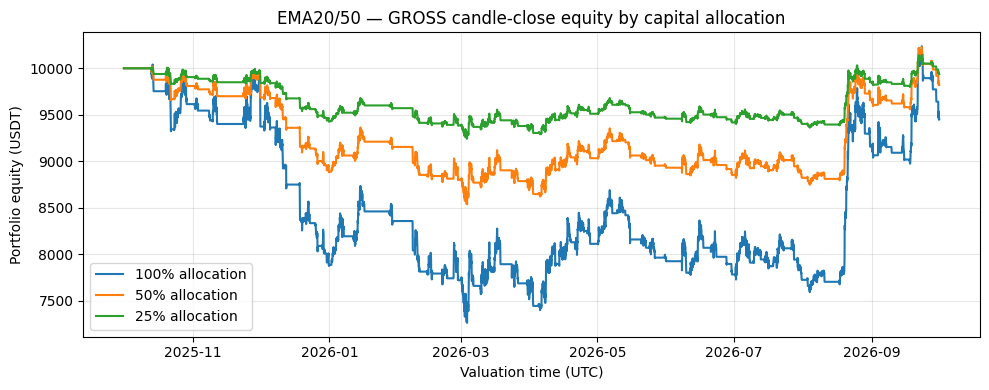

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for fraction in FRACTIONS:
    path = paths[fraction]["GROSS"]
    ax.plot(path.valuation_time, path.equity, label=f"{fraction:.0%} allocation")
ax.set_title("EMA20/50 — GROSS candle-close equity by capital allocation")
ax.set_xlabel("Valuation time (UTC)")
ax.set_ylabel("Portfolio equity (USDT)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 8. NET equity across allocations

NET includes the modeled costs actually incurred, with self-financing entry
sizing and independent compounding. Repeated round trips weaken this sample's
results. The difference from GROSS includes fees, adverse slippage, and the
subsequent effect on sizing, rather than only a sum of fees.

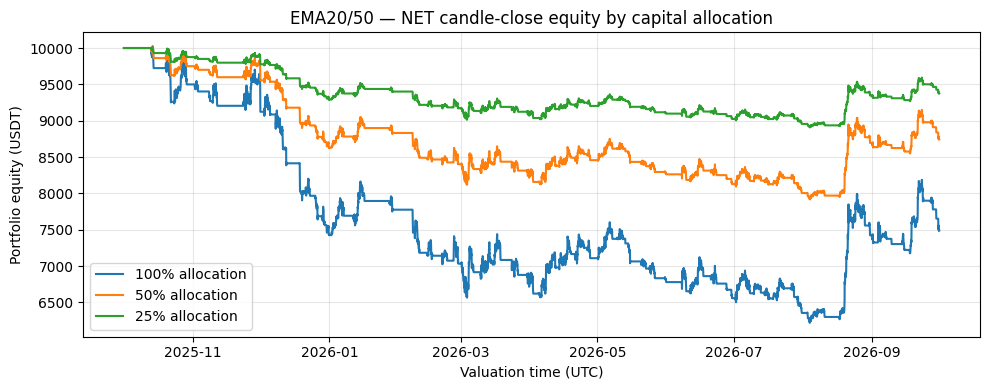

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for fraction in FRACTIONS:
    path = paths[fraction]["NET"]
    ax.plot(path.valuation_time, path.equity, label=f"{fraction:.0%} allocation")
ax.set_title("EMA20/50 — NET candle-close equity by capital allocation")
ax.set_xlabel("Valuation time (UTC)")
ax.set_ylabel("Portfolio equity (USDT)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 9. Performance: realized capital, marked equity, and risk

The compact comparison has 12 measurements and three allocation columns. Every
value is selected from canonical accounting or an existing analytics API.
Capital/equity is in USDT; drawdowns are negative decimal fractions (−0.10 means
−10%); Sharpe and Sortino are dimensionless. Display rounding does not affect
stored values or reference assertions.

**Realized drawdown** observes initial capital and post-CLOSED capital only. It
can miss losses inside a trade. **Portfolio drawdown** observes every candle
CLOSE, including final OPEN marks; it can still miss intrabar lows.

**Sharpe** measures mean excess hourly portfolio return relative to sample
standard deviation (`ddof=1`). **Sortino** uses return above MAR relative to
root-mean-square downside across **all periods**, with non-downside periods
contributing zero. Both use 8,760 periods/year and zero hourly risk-free return
and MAR under Decision 009. Cash zero-return periods are retained. The production
helpers implement these conventions; the notebook does not recalculate formulas.

In [10]:
performance_columns = {}
for fraction, result in pipelines.items():
    gross, net = result["gross_results"], result["net_results"]
    gross_path, net_path = paths[fraction]["GROSS"], paths[fraction]["NET"]
    gross_risk = summarize_risk_adjusted_performance(
        gross_path, periods_per_year=8760, risk_free_return_per_period=0.0,
        minimum_acceptable_return_per_period=0.0, label="GROSS",
    ).loc["GROSS"]
    net_risk = summarize_risk_adjusted_performance(
        net_path, periods_per_year=8760, risk_free_return_per_period=0.0,
        minimum_acceptable_return_per_period=0.0, label="NET",
    ).loc["NET"]
    assert gross_risk.period_count == net_risk.period_count == 8760
    performance_columns[f"{fraction:.0%}"] = {
        "last_closed_gross": gross.loc[gross.status.eq("CLOSED"), "capital_after"].iloc[-1],
        "last_closed_net": net.loc[net.status.eq("CLOSED"), "net_capital_after"].iloc[-1],
        "final_gross_mtm": gross_path.equity.iloc[-1], "final_net_mtm": net_path.equity.iloc[-1],
        "realized_gross_dd": summarize_gross_realized_drawdown(gross, INITIAL_CAPITAL).loc["GROSS", "max_realized_drawdown"],
        "realized_net_dd": summarize_net_realized_drawdown(net, INITIAL_CAPITAL).loc["NET", "max_realized_drawdown"],
        "portfolio_gross_dd": summarize_gross_portfolio_drawdown(gross_path).loc["GROSS", "max_portfolio_drawdown"],
        "portfolio_net_dd": summarize_net_portfolio_drawdown(net_path).loc["NET", "max_portfolio_drawdown"],
        "gross_sharpe": gross_risk.sharpe_ratio, "gross_sortino": gross_risk.sortino_ratio,
        "net_sharpe": net_risk.sharpe_ratio, "net_sortino": net_risk.sortino_ratio,
    }
performance = pd.DataFrame(performance_columns)
assert performance.shape == (12, 3) and np.isfinite(performance).all().all()
display(performance.round(6))

,100%,50%,25%
last_closed_gross,9641.111388,9918.391237,9985.739621
last_closed_net,7652.530163,8837.511198,9426.098542
final_gross_mtm,9451.485314,9820.851362,9936.638524
final_net_mtm,7490.776563,8744.110765,9376.288043
realized_gross_dd,-0.267234,-0.142485,-0.073577
realized_net_dd,-0.371855,-0.204238,-0.107045
portfolio_gross_dd,-0.276794,-0.148091,-0.076608
portfolio_net_dd,-0.379680,-0.209201,-0.109831
gross_sharpe,-0.065421,-0.058162,-0.054056
gross_sortino,-0.095535,-0.085075,-0.079143


## 10. Allocation and time exposure are different dimensions

In this **particular losing BTC window**, smaller allocations finish closer to
10,000 and have shallower drawdowns. This is dataset-specific, not a general
claim that smaller allocation improves a strategy. Smaller fractions reduce
participation in upside as well as downside and do not repair negative expectancy.

Sharpe/Sortino do not shrink in simple proportion to the fraction: both numerator
and denominator change on total-portfolio hourly returns, and reserve changes the
cash/holding path. A higher numerical ratio alone is not proof of better signals.

Binary time exposure asks whether a position was held, not its capital weight.
The same fills therefore produce the same holding durations and exposure at all
three fractions. The final OPEN trade contributes 11 observed hours, without an
invented completed duration. The next table is produced from each unchanged ledger.

In [11]:
time_summaries = {}
for fraction, result in pipelines.items():
    summary = summarize_trade_time_metrics(result["trades"], START, END)
    time_summaries[fraction] = summary
    pd.testing.assert_frame_equal(summary, time_summaries[1.0], check_exact=True)
    np.testing.assert_allclose(summary.loc["TIME", [
        "closed_trade_count", "open_trade_count", "total_closed_duration_hours",
        "open_observed_duration_hours", "total_time_in_market_hours", "observation_window_hours", "exposure_ratio",
    ]].to_numpy(dtype=float), [77, 1, 4078, 11, 4089, 8760, 0.46678082191780823], rtol=1e-12, atol=1e-12)
time_fields = [
    "closed_trade_count", "open_trade_count", "total_closed_duration_hours",
    "open_observed_duration_hours", "total_time_in_market_hours", "observation_window_hours", "exposure_ratio",
]
display(pd.DataFrame({
    f"{fraction:.0%}": summary.loc["TIME", time_fields] for fraction, summary in time_summaries.items()
}).round(9))

,100%,50%,25%
closed_trade_count,77.000000,77.000000,77.000000
open_trade_count,1.000000,1.000000,1.000000
total_closed_duration_hours,4078.000000,4078.000000,4078.000000
open_observed_duration_hours,11.000000,11.000000,11.000000
total_time_in_market_hours,4089.000000,4089.000000,4089.000000
observation_window_hours,8760.000000,8760.000000,8760.000000
exposure_ratio,0.466781,0.466781,0.466781


## 11. Trade returns have different denominators

GROSS `trade_return` is the raw **position price return**, independent of allocation.
NET `net_trade_return` is `net_pnl / capital_before`, where capital before means
**total portfolio capital**, including the part held in reserve. These fields
keep their existing meanings; partial allocation makes the distinction visible.

Without costs, a price move 100 → 110 gives a 10% position return. At half
allocation it contributes 5% to total portfolio capital. The actual first CLOSED
trade below reads the two existing return fields without recomputing either.

In [12]:
return_preview = pd.DataFrame({
    f"{fraction:.0%}": {
        "GROSS_position_trade_return": result["gross_results"].trade_return.iloc[0],
        "NET_portfolio_trade_return": result["net_results"].net_trade_return.iloc[0],
    } for fraction, result in pipelines.items()
})
assert return_preview.loc["GROSS_position_trade_return"].nunique() == 1
display(return_preview.round(9))

,100%,50%,25%
GROSS_position_trade_return,-0.024714,-0.024714,-0.024714
NET_portfolio_trade_return,-0.027635,-0.013818,-0.006909


## 12. Check the accepted BTC references

These small headline reference assertions complement the authoritative Stage 7.7
regression tests. They do not import tests or replace their broader coverage.
The four full-allocation capital/equity references remain frozen from Stage 5/6;
the 50%/25% comparison matches the accepted 12-field Stage 7.7 snapshots.

Constants below are **expected values only**. All tables and plots above use
computed production outputs. Capital, equity, and drawdown/ratio checks retain
the regression's respective tolerances; no tolerance is loosened here.

In [13]:
# Expected values in performance row order; never inputs to financial calculations.
full_capital_references = [9641.111388344, 7652.530163437, 9451.485313939314, 7490.776562851941]
partial_references = {
    "50%": [
        9918.391236748259, 8837.511197655364, 9820.851361993184, 8744.110764994484,
        -0.14248540505494767, -0.20423832781018214, -0.14809055437971497, -0.20920070404661006,
        -0.058161849146260235, -0.08507501805626921, -0.8824772122392462, -1.2814314707945054,
    ],
    "25%": [
        9985.739621448789, 9426.098541539295, 9936.638523863317, 9376.288042723892,
        -0.07357702428688317, -0.1070450228128268, -0.07660787284120885, -0.10983103209615619,
        -0.054056339584623025, -0.07914256241587235, -0.8712069545635516, -1.2663722258083463,
    ],
}
references = {"100%": full_capital_references, **partial_references}
for allocation, expected in references.items():
    actual = performance[allocation].to_numpy()
    np.testing.assert_allclose(actual[:2], expected[:2], rtol=1e-10)
    np.testing.assert_allclose(actual[2:4], expected[2:4], rtol=1e-12, atol=1e-9)
    if allocation != "100%":
        np.testing.assert_allclose(actual[4:], expected[4:], rtol=1e-12, atol=1e-14)
print("Frozen full-allocation capital/equity and both partial analytics snapshots: passed")

Frozen full-allocation capital/equity and both partial analytics snapshots: passed


## 13. Final OPEN position: marked, never closed

Last CLOSED capital is available before entering trade 78; it is not the cash
left after that entry. The final mark below separates reserve from the holding's
value. Partial allocation retains positive cash while LONG; full allocation has
zero reserve. Ledger exit fields and realized results remain missing.

No sale is invented at the last CLOSE. NET final equity includes the entry fee
already incurred but excludes hypothetical exit costs. The separate Buy-and-Hold
benchmark remains independently full-allocated; changing strategy allocation does
not resize that benchmark. This notebook does not repeat its benchmark analysis.

In [14]:
open_rows = []
for fraction, result in pipelines.items():
    assert result["trades"].iloc[-1][["exit_time", "exit_price"]].isna().all()
    for label, key, realized_fields in (
        ("GROSS", "gross_results", ["trade_return", "gross_pnl", "capital_after"]),
        ("NET", "net_results", ["net_pnl", "net_trade_return", "net_capital_after", "total_fees"]),
    ):
        last_trade = result[key].iloc[-1]
        last_mark = paths[fraction][label].iloc[-1]
        assert last_trade.status == "OPEN" and last_trade[realized_fields].isna().all()
        assert last_mark.equity == last_mark.cash + last_mark.position_value
        open_rows.append({
            "path": f"{label} {fraction:.0%}", "status": last_trade.status,
            "capital_before_USDT": last_trade.capital_before, "quantity_BTC": last_trade.quantity,
            "reserve_USDT": last_mark.cash, "holding_value_USDT": last_mark.position_value,
            "marked_equity_USDT": last_mark.equity,
        })
display(pd.DataFrame(open_rows).set_index("path").round(6))

,status,capital_before_USDT,quantity_BTC,reserve_USDT,holding_value_USDT,marked_equity_USDT
path,,,,,,
GROSS 100%,OPEN,9641.111388,0.113034,0.000000,9451.485314,9451.485314
NET 100%,OPEN,7652.530163,0.089585,0.000000,7490.776563,7490.776563
GROSS 50%,OPEN,9918.391237,0.058143,4959.195618,4861.655744,9820.851362
NET 50%,OPEN,8837.511198,0.051729,4418.755599,4325.355166,8744.110765
GROSS 25%,OPEN,9985.739621,0.029269,7489.304716,2447.333808,9936.638524
NET 25%,OPEN,9426.098542,0.027587,7069.573906,2306.714137,9376.288043


## 14. Preservation and notebook audit

The final checks compare deep copies of market candles, the shared strategy
output, all four pipeline frames for every fraction, and all six equity sources.
Time-based returns also retain the complete 8,760-period clock and cash zeros.
The raw CSV's before/after hash must match. No dataset or separate report is saved.

These notebook sanity checks accompany the unchanged production regression suite.
They do not rerun earlier notebooks or turn this research into a trading runtime.

In [15]:
pd.testing.assert_frame_equal(candles, candles_before, check_exact=True)
pd.testing.assert_frame_equal(strategy_output, strategy_before, check_exact=True)
for fraction, result in pipelines.items():
    for key, frame in result.items():
        pd.testing.assert_frame_equal(frame, pipeline_before[fraction][key], check_exact=True)
    for label, path in paths[fraction].items():
        returns = calculate_time_based_returns(path)
        assert len(returns) == 8760
        assert returns.period_start_time.iloc[0] == START and returns.period_end_time.iloc[-1] == END
        assert returns.period_return.iloc[0] == 0.0 and returns.period_return.eq(0).any()
        pd.testing.assert_frame_equal(path, equity_before[fraction][label], check_exact=True)
assert hashlib.sha256(CSV_PATH.read_bytes()).hexdigest() == raw_hash_before == FROZEN_SHA256

display(pd.Series({
    "snapshot_identity_and_raw_bytes": "preserved",
    "shared_strategy_and_all_pipeline_frames": "preserved",
    "equity_sources_and_full_hourly_clock": "preserved",
    "execution_ledger_and_time_exposure": "identical across fractions",
    "full_and_partial_reference_checks": "passed",
    "final_trade_78": "OPEN; marked without liquidation",
    "network_calls_or_downloads": "none",
}, name="Research audit").to_frame())

,Research audit
snapshot_identity_and_raw_bytes,preserved
shared_strategy_and_all_pipeline_frames,preserved
equity_sources_and_full_hourly_clock,preserved
execution_ledger_and_time_exposure,identical across fractions
full_and_partial_reference_checks,passed
final_trade_78,OPEN; marked without liquidation
network_calls_or_downloads,none


## Takeaways

- Signal quality and capital participation are separate decisions. Sizing changes
  the strength of participation; it does not improve entry/exit timing.
- Each budget uses current total capital. GROSS and NET compound independently.
- Reserve stays in the portfolio and is included in equity. Entry fees are paid
  once; repeated costs matter beyond their simple sum.
- Binary time exposure stays unchanged even when capital allocation changes.
- Smaller fractions reduce both upside and downside participation. Their shallower
  drawdowns here describe one losing dataset, not a universal strategy result.
- Default 1.0 preserves the existing full-allocation baseline. The 0.50/0.25 paths
  are research comparisons, not recommendations or optimized parameters.

## Limitations and next boundary

The implemented policy is one fixed scalar fraction, `0 < position_fraction <= 1`,
for a single LONG/FLAT spot-style position. There is no leverage, short selling,
margin, stop loss, take profit, volatility targeting, ATR sizing, Kelly sizing,
dynamic fraction, multi-asset portfolio, or multi-bot allocator. Candle-CLOSE
valuation cannot show every intrabar loss. Cash earns no modeled interest.

This notebook uses one historical window and one EMA configuration. It performs
no optimization, out-of-sample validation, or walk-forward research, and provides
no evidence of future profitability. Live/demo execution and broader risk controls
remain future work.

Stage 7.8 ends with this educational comparison. **Stage 7.9 — Final Stage 7 Audit
+ Docs** requires explicit owner approval and has not started; Stage 7 is not yet
complete.